1. Importar todas las librerias necesarias. (+0.15 puntos)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns

2. Inicializar algunas variables que despues modificaremos. (+0.15 puntos)

In [13]:
hostnames = []
dataset = []
df = []

3. Crear una funcion para generar los hostnames a base a unas reglas (+1.5 puntos)

In [14]:
def set_hostnames(number_of_hosts: int) -> None:
  hostnames_SO = ['L']*40 + ['S']*30 + ['A']*20 + ['H']*10
  hostnames_entorno = ['D']*10 + ['I']*10 + ['T']*25 + ['S']*25 + ['P']*30
  hostnames_pais = ['NOR']*6 + ['FRA']*9 + ['ITA']*16 + ['ESP']*16 + ['DEU']*23 + ['IRL']*30
  grupo_alpha = []

  for i in range(number_of_hosts):
    hostname = random.choice(hostnames_SO) + random.choice(hostnames_entorno) + random.choice(hostnames_pais)
    grupo_alpha.append(hostname)
    hostname += str(grupo_alpha.count(hostname)).zfill(3)
    hostnames.append(hostname)

4. Crear una función para obtener el nombre del SO. (+0.5 puntos)

In [15]:
def get_os(hostname: str) -> str:
  if hostname.startswith('L'):
    return 'Linux'
  elif hostname.startswith('S'):
    return 'Solaris'
  elif hostname.startswith('A'):
    return 'AIX'
  elif hostname.startswith('H'):
    return 'HPUX'
  else:
    return 'Unknown'

5.Crear una función para obtener el nombre del entorno. (+0.5 puntos)

In [16]:
def get_enviroment(hostname: str) -> str:
  enviroment = hostname[1]
  if enviroment == 'D':
    return 'Development'
  elif enviroment == 'I':
    return 'Integration'
  elif enviroment == 'T':
    return 'Testing'
  elif enviroment == 'S':
    return 'Staging'
  elif enviroment == 'P':
    return 'Production'
  else:
    return 'Unknown'

6. Crear una funcion para obtener el nombre del país. (+0.5 puntos)

In [17]:
def get_country(hostname: str) -> str:
  country = hostname[2:5]
  if country == 'NOR':
    return 'Norway'
  elif country == 'FRA':
    return 'France'
  elif country == 'ITA':
    return 'Italy'
  elif country == 'ESP':
    return 'Spain'
  elif country == 'DEU':
    return 'Germany'
  elif country == 'IRL':
    return 'Ireland'
  else:
    return 'Unknown'

7. Crear una función para generar el DataFrame. (+1 punto)

In [18]:
def set_dataframe(count: int)-> None:
  global df

  set_hostnames(count)
  for código in hostnames:
    dataset.append({
                  "hostname": código,
                  "os": get_os(código),
                  "enviroment": get_enviroment(código),
                  "country": get_country(código),
                  "node": int(código[-3])
                  })
  df = pd.DataFrame(dataset)

8. Crear el DataFrame (+0.2 puntos)

In [19]:
set_dataframe(1500)
df

,hostname,os,enviroment,country,node
0,LPITA001,Linux,Production,Italy,0
1,ATIRL001,AIX,Testing,Ireland,0
2,LSESP001,Linux,Staging,Spain,0
3,ATITA001,AIX,Testing,Italy,0
4,LTIRL001,Linux,Testing,Ireland,0
...,...,...,...,...,...
1495,LSIRL039,Linux,Staging,Ireland,0
1496,ADDEU012,AIX,Development,Germany,0
1497,STFRA015,Solaris,Testing,France,0
1498,SSFRA010,Solaris,Staging,France,0


9. Guardar el DataFrame generado en un fichero CSV. (+0.5 puntos)

In [20]:
df.to_csv(
   'hosts.csv',
   header=True,
   index=False,
)
df_hosts = pd.read_csv('hosts.csv')
df_hosts


,hostname,os,enviroment,country,node
0,LPITA001,Linux,Production,Italy,0
1,ATIRL001,AIX,Testing,Ireland,0
2,LSESP001,Linux,Staging,Spain,0
3,ATITA001,AIX,Testing,Italy,0
4,LTIRL001,Linux,Testing,Ireland,0
...,...,...,...,...,...
1495,LSIRL039,Linux,Staging,Ireland,0
1496,ADDEU012,AIX,Development,Germany,0
1497,STFRA015,Solaris,Testing,France,0
1498,SSFRA010,Solaris,Staging,France,0


10. Generar un único gráfico, agrupando para cada país (country) los entornos (enviroment). (+0.5 puntos)

<Axes: xlabel='country'>

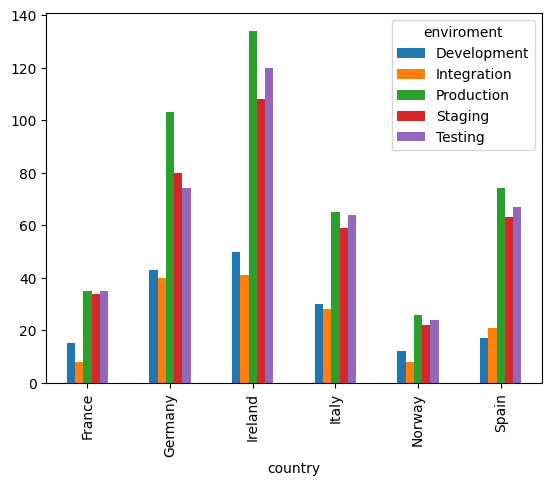

In [21]:
c = df.groupby(['country', 'enviroment']).size()
c.unstack().plot(kind='bar')


11. Crear una figura con 4 gráficos en una malla de 2 filas y 2 columnas. (+4.5 puntos)

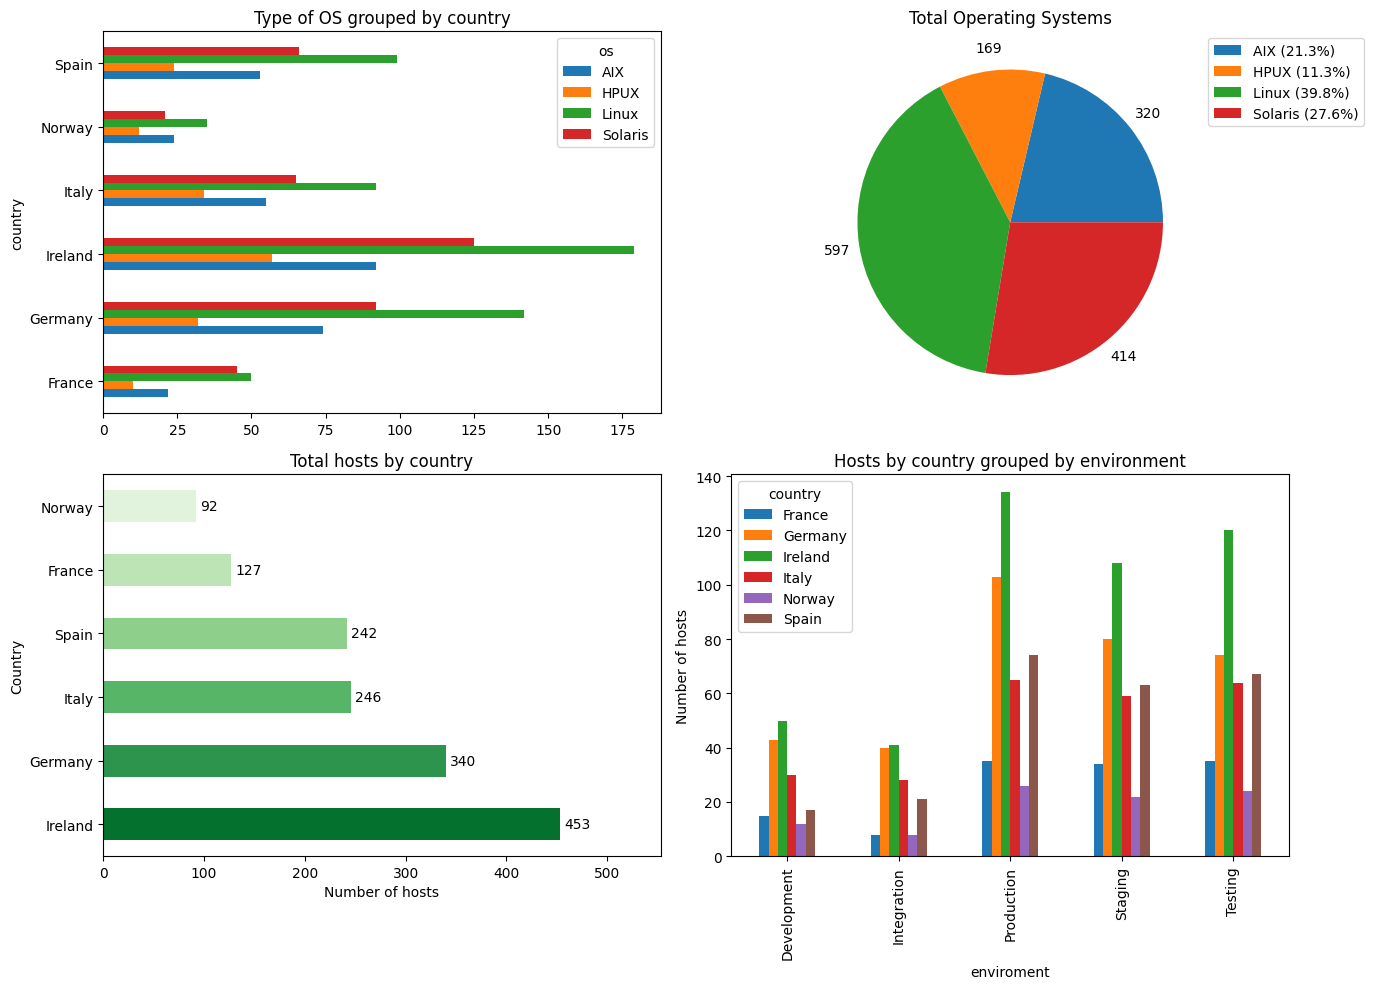

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].set_title('Type of OS grouped by country')
os_by_country = df.groupby(['country', 'os']).size().unstack(fill_value=0)
os_by_country.plot(kind='barh', ax=axs[0, 0])


axs[0, 1].set_title('Total Operating Systems')
os = df.groupby(['os']).size()
os.plot(kind='pie',
        labels=None,
        ax=axs[0,1],
        autopct=lambda p: f"{int(round(p * os.sum() / 100))}",
        pctdistance=1.15
        )
porcentajes = os / os.sum() * 100
labels = [f"{so} ({p:.1f}%)" for so, p in zip(os.index, porcentajes)]
axs[0,1].legend(
    labels,
    loc='upper left',
    bbox_to_anchor=(1, 1)
)


axs[1, 0].set_title('Total hosts by country')
paises = df['country'].value_counts()
colores = sns.color_palette("Greens", n_colors=len(paises))
colores = colores[::-1]
paises.plot(kind='barh', ax=axs[1,0], color=colores)
axs[1,0].set_ylabel('Country')
axs[1,0].set_xlabel('Number of hosts')
for cantidad in axs[1,0].containers:
    axs[1,0].bar_label(cantidad, fmt='%d', label_type='edge', padding=3)
max_hosts = paises.max()
axs[1,0].set_xlim(0, max_hosts + 100)


axs[1, 1].set_title('Hosts by country grouped by environment')
enviroment_by_country = (
    df.groupby(['country', 'enviroment'])['hostname']
      .count()
      .unstack(0)
)
enviroment_by_country.plot(kind='bar', ax=axs[1, 1])
axs[1,1].set_ylabel('Number of hosts')


plt.tight_layout()
plt.show()
